# Data Processing & Preparation

Load, clean, and prepare historical stock price data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
# Load data
df = pd.read_csv("all_stocks_5yr.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (619040, 7)

Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

First few rows:


,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [3]:
# Data info
print("Data Info:")
df.info()
print(f"\nBasic Statistics:")
df.describe()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 40.8 MB

Basic Statistics:


,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [4]:
# Data cleaning
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64


In [5]:
# Filter stocks
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]
df = df[df['Name'].isin(stocks)]

print(f"Stocks selected: {stocks}")
print(f"Filtered dataset shape: {df.shape}")
print(f"Unique stocks: {df['Name'].unique()}")

Stocks selected: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'XOM', 'NVDA']
Filtered dataset shape: (8813, 7)
Unique stocks: <ArrowStringArray>
['XOM', 'AMZN', 'AAPL', 'JPM', 'GOOGL', 'NVDA', 'MSFT']
Length: 7, dtype: str


In [6]:
# Pivot data - convert to wide format (each column = stock)
price_df = df.pivot(index='date', columns='Name', values='close')
price_df = price_df.sort_index()

print(f"Pivoted price data shape: {price_df.shape}")
print(f"\nDate range: {price_df.index[0].date()} to {price_df.index[-1].date()}")
print(f"\nPrice data (first 5 rows):")
price_df.head()

Pivoted price data shape: (1259, 7)

Date range: 2013-02-08 to 2018-02-07

Price data (first 5 rows):


Name,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA,XOM
date,,,,,,,
2013-02-08,67.8542,261.95,393.0777,48.63,27.55,12.37,88.61
2013-02-11,68.5614,257.21,391.6012,48.66,27.86,12.51,88.28
2013-02-12,66.8428,258.70,390.7403,49.14,27.88,12.43,88.46
2013-02-13,66.7156,269.47,391.8214,48.68,28.03,12.37,88.67
2013-02-14,66.6556,269.24,394.3039,49.22,28.04,12.73,88.52


In [7]:
# Calculate returns
returns = price_df.pct_change().dropna()
log_returns = np.log(price_df / price_df.shift(1)).dropna()

print(f"Simple returns shape: {returns.shape}")
print(f"\nReturns statistics:")
print(returns.describe())

Simple returns shape: (1258, 7)

Returns statistics:
Name          AAPL         AMZN        GOOGL          JPM         MSFT  \
count  1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean      0.000786     0.001508     0.000880     0.000752     0.001039   
std       0.014593     0.018235     0.013880     0.012844     0.014210   
min      -0.079927    -0.109972    -0.054141    -0.069477    -0.113995   
25%      -0.006397    -0.007047    -0.005642    -0.005651    -0.005832   
50%       0.000435     0.001050     0.000610     0.000640     0.000471   
75%       0.008631     0.010801     0.007696     0.007580     0.007751   
max       0.081982     0.141311     0.162584     0.083286     0.104522   

Name          NVDA          XOM  
count  1258.000000  1258.000000  
mean      0.002563    -0.000051  
std       0.022350     0.011026  
min      -0.092723    -0.056903  
25%      -0.007525    -0.005541  
50%       0.001673    -0.000120  
75%       0.011983     0.005735  
max     

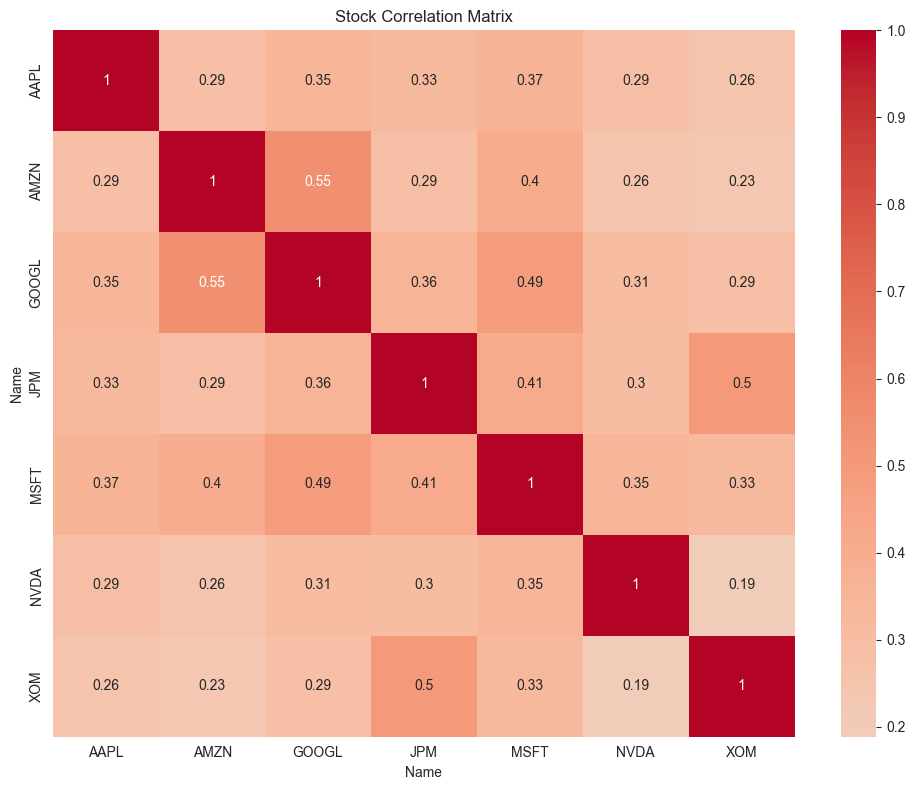

Correlation Matrix:
Name    AAPL   AMZN  GOOGL    JPM   MSFT   NVDA    XOM
Name                                                  
AAPL   1.000  0.288  0.349  0.328  0.367  0.290  0.256
AMZN   0.288  1.000  0.548  0.291  0.403  0.258  0.235
GOOGL  0.349  0.548  1.000  0.356  0.488  0.307  0.286
JPM    0.328  0.291  0.356  1.000  0.413  0.300  0.499
MSFT   0.367  0.403  0.488  0.413  1.000  0.345  0.326
NVDA   0.290  0.258  0.307  0.300  0.345  1.000  0.189
XOM    0.256  0.235  0.286  0.499  0.326  0.189  1.000


In [8]:
# Correlation analysis
plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Stock Correlation Matrix')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(returns.corr().round(3))

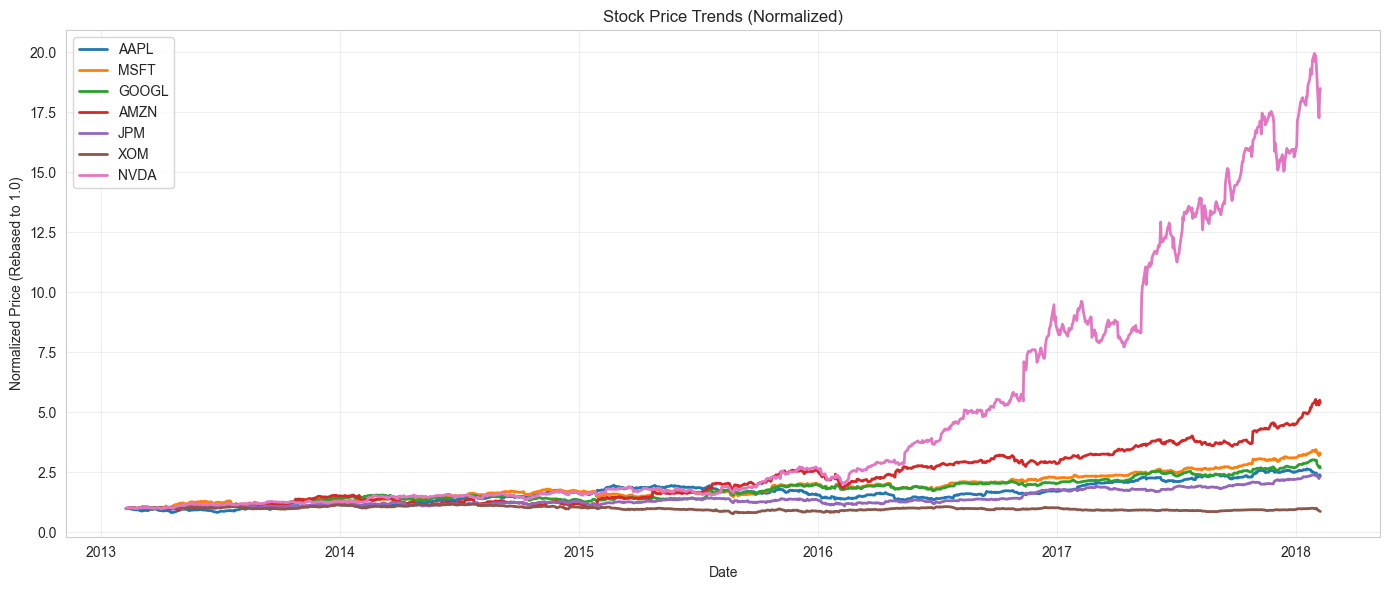

In [9]:
# Price trends
plt.figure(figsize=(14, 6))
for stock in stocks:
    normalized = price_df[stock] / price_df[stock].iloc[0]
    plt.plot(normalized.index, normalized.values, label=stock, linewidth=2)

plt.xlabel('Date')
plt.ylabel('Normalized Price (Rebased to 1.0)')
plt.title('Stock Price Trends (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Save processed data
print("\n✓ Data Processing Complete")
print(f"\nDatasets ready for feature engineering:")
print(f"  • price_df: {price_df.shape}")
print(f"  • returns: {returns.shape}")
print(f"  • stocks list: {len(stocks)} stocks")


✓ Data Processing Complete

Datasets ready for feature engineering:
  • price_df: (1259, 7)
  • returns: (1258, 7)
  • stocks list: 7 stocks


In [11]:
# Save processed data as CSV for other notebooks
price_df.to_csv('price_data.csv')
returns.to_csv('returns_data.csv')

print("✓ Data saved to CSV files")
print(f"  • price_data.csv: {price_df.shape}")
print(f"  • returns_data.csv: {returns.shape}")

✓ Data saved to CSV files
  • price_data.csv: (1259, 7)
  • returns_data.csv: (1258, 7)
